In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'HHS_Unaccompanied_Alien_Children_Program.csv'

In [3]:
# df.shape
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [4]:
df.shape

(1170, 6)

In [5]:
df.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [7]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [8]:
df.tail(450)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
720,NaN,NaN,NaN,NaN,NaN,NaN
721,NaN,NaN,NaN,NaN,NaN,NaN
722,NaN,NaN,NaN,NaN,NaN,NaN
723,NaN,NaN,NaN,NaN,NaN,NaN
724,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1165,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df.dropna(how="all")

In [10]:
df.shape

(720, 6)

In [11]:
df.isnull().sum()

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 39.4+ KB


cnvt date from object to datetime format

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
df["Children in HHS Care"].unique()[:10]

array(['2,484', '2,472', '2,481', '2,468', '2,470', '2,462', '2,437',
       '2,439', '2,443', '2,440'], dtype=object)

In [15]:
df["Children in HHS Care"].head(10)

0    2,484
1    2,472
2    2,481
3    2,468
4    2,470
5    2,462
6    2,437
7    2,439
8    2,443
9    2,440
Name: Children in HHS Care, dtype: object

cnvt hhs columns into number format from object

In [16]:
df["Children in HHS Care"] = (
    df["Children in HHS Care"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

columns rename  

In [17]:
df.rename(columns={
    "Children apprehended and placed in CBP custody*":
    "Children apprehended and placed in CBP custody"
}, inplace=True)


Basic EDA

In [18]:
df.describe()

,Date,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


Date Features

In [19]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Month_Num"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.day_name()

KPIS(key performaance indecator)

transfer efficiency ratio 


In [20]:
# Transfers / CBP Custody
df["Transfer Efficiency Ratio"] = (
    df["Children transferred out of CBP custody"] /
    df["Children in CBP custody"]
)

2. Discharge Effectiveness Index

In [21]:
df["Discharge Effectiveness"] = (
    df["Children discharged from HHS Care"] /
    df["Children in HHS Care"]
)
# Discharges / HHS Care

3. Pipeline Throughput

In [22]:
df["Pipeline Throughput"] = (
    df["Children discharged from HHS Care"] /
    df["Children apprehended and placed in CBP custody"]
)
# dischargess/apprehensions

4. Backlog Accumulation

In [23]:
df["Backlog"] = (
    df["Children apprehended and placed in CBP custody"] -
    df["Children discharged from HHS Care"]
)
# Apprehensions - Discharges

In [24]:
df.head()
# check new cols

,Date,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Month_Num,Weekday,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog
0,2025-12-21,6.0,18.0,11.0,2484,14.0,2025,December,12,Sunday,0.611111,0.005636,2.333333,-8.0
1,2025-12-18,11.0,50.0,6.0,2472,16.0,2025,December,12,Thursday,0.120000,0.006472,1.454545,-5.0
2,2025-12-17,7.0,31.0,11.0,2481,10.0,2025,December,12,Wednesday,0.354839,0.004031,1.428571,-3.0
3,2025-12-16,8.0,54.0,15.0,2468,9.0,2025,December,12,Tuesday,0.277778,0.003647,1.125000,-1.0
4,2025-12-15,11.0,42.0,9.0,2470,7.0,2025,December,12,Monday,0.214286,0.002834,0.636364,4.0


outlier check

In [25]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Children apprehended and placed in CBP custody: 0 outliers
Children in CBP custody: 0 outliers
Children transferred out of CBP custody: 0 outliers
Children in HHS Care: 0 outliers
Children discharged from HHS Care: 0 outliers
Transfer Efficiency Ratio: 15 outliers
Discharge Effectiveness: 0 outliers
Pipeline Throughput: 59 outliers
Backlog: 12 outliers


correlation matrix

In [26]:
corr = df.corr(numeric_only=True)

corr

,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month_Num,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog
Children apprehended and placed in CBP custody,1.000000,0.950604,0.887896,0.691312,0.627755,-0.587536,-0.033216,0.309898,0.624407,-0.340213,-0.063887
Children in CBP custody,0.950604,1.000000,0.925039,0.663662,0.602144,-0.542306,-0.056665,0.259962,0.601596,-0.346047,-0.067651
Children transferred out of CBP custody,0.887896,0.925039,1.000000,0.713899,0.657322,-0.589598,-0.056778,0.505824,0.658906,-0.290544,-0.184853
Children in HHS Care,0.691312,0.663662,0.713899,1.000000,0.920881,-0.872610,-0.000952,0.538288,0.784222,0.096286,-0.668401
Children discharged from HHS Care,0.627755,0.602144,0.657322,0.920881,1.000000,-0.834188,-0.075050,0.521907,0.924798,0.196699,-0.816926
Year,-0.587536,-0.542306,-0.589598,-0.872610,-0.834188,1.000000,-0.054740,-0.484138,-0.742554,-0.128551,0.634147
Month_Num,-0.033216,-0.056665,-0.056778,-0.000952,-0.075050,-0.054740,1.000000,-0.140366,-0.181639,-0.130979,0.071607
Transfer Efficiency Ratio,0.309898,0.259962,0.505824,0.538288,0.521907,-0.484138,-0.140366,1.000000,0.564678,0.120517,-0.439497
Discharge Effectiveness,0.624407,0.601596,0.658906,0.784222,0.924798,-0.742554,-0.181639,0.564678,1.000000,0.207999,-0.722995
Pipeline Throughput,-0.340213,-0.346047,-0.290544,0.096286,0.196699,-0.128551,-0.130979,0.120517,0.207999,1.000000,-0.503415


heatmap

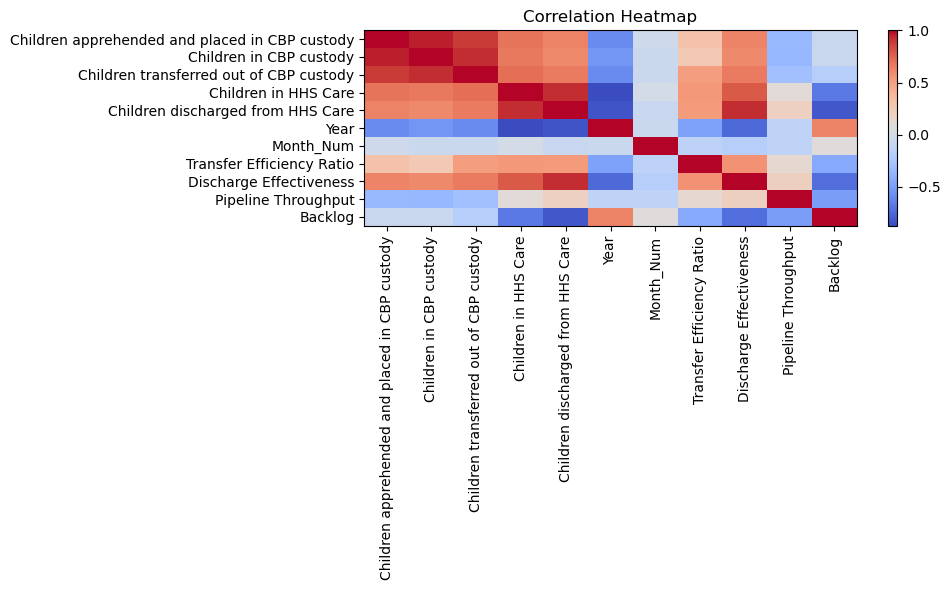

In [27]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# Trend Charts

1. Children Apprehended

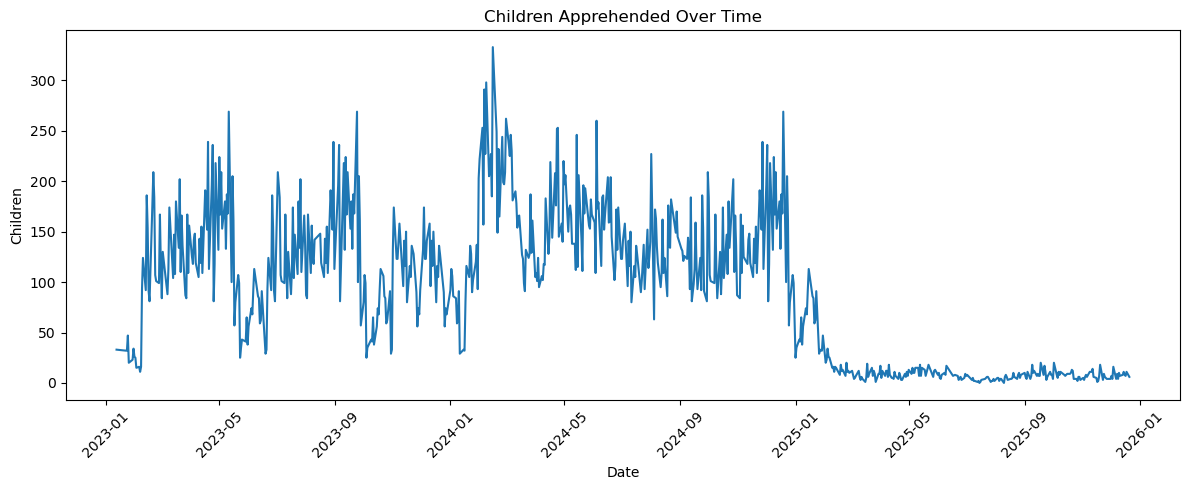

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children apprehended and placed in CBP custody"],
)

plt.title("Children Apprehended Over Time")

plt.xlabel("Date")

plt.ylabel("Children")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

2. Children in CBP Custody

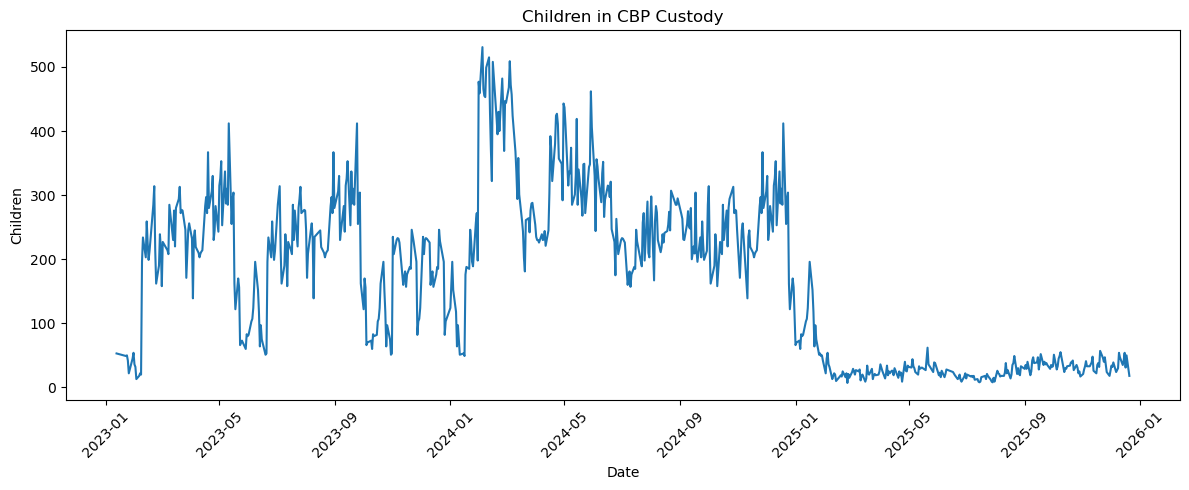

In [29]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children in CBP custody"],
)

plt.title("Children in CBP Custody")

plt.xlabel("Date")

plt.ylabel("Children")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

3. Children Transferred

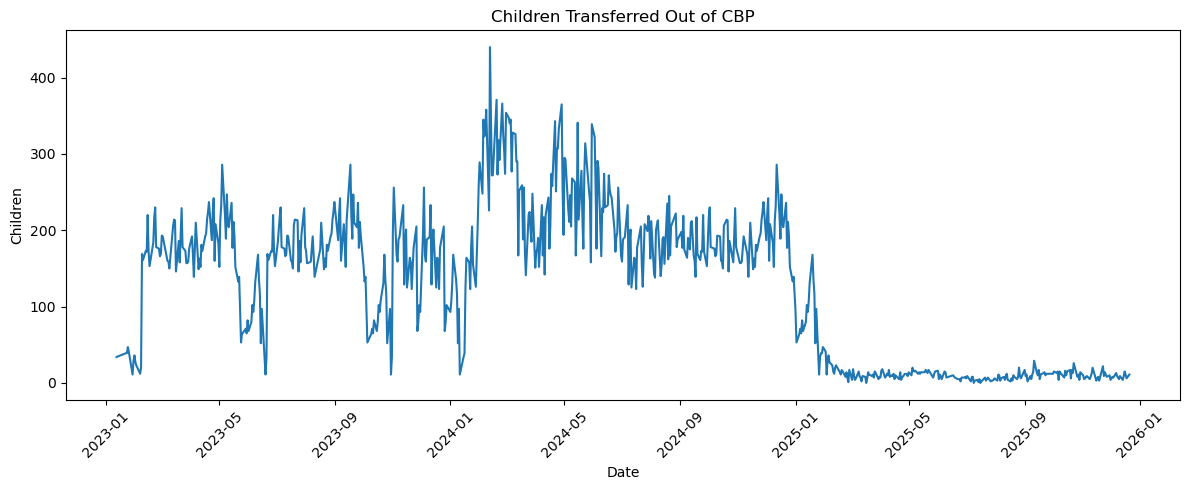

In [30]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children transferred out of CBP custody"],
)

plt.title("Children Transferred Out of CBP")

plt.xlabel("Date")

plt.ylabel("Children")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

4. Children in HHS Care

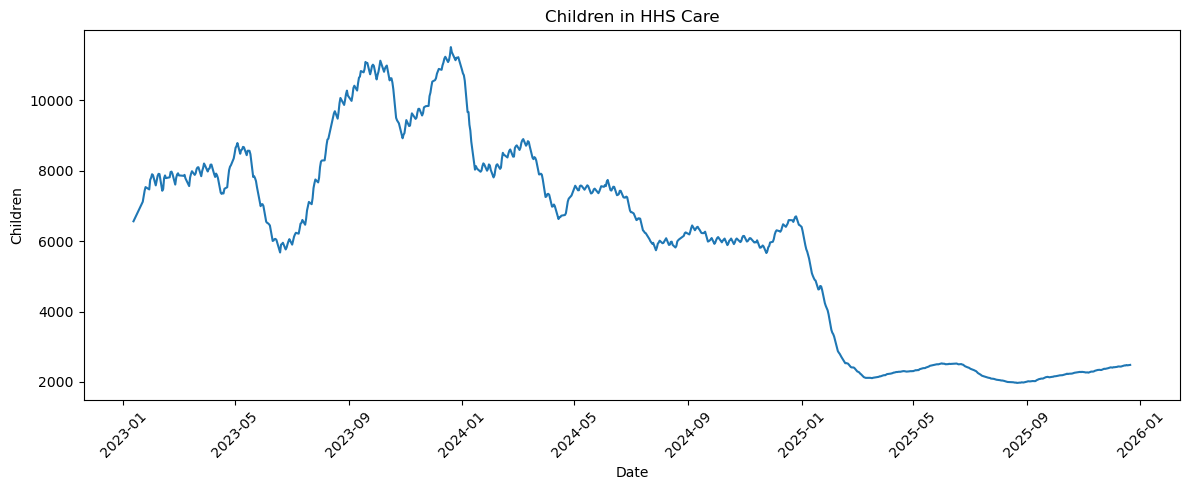

In [31]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
)

plt.title("Children in HHS Care")

plt.xlabel("Date")

plt.ylabel("Children")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

5. Children Discharged

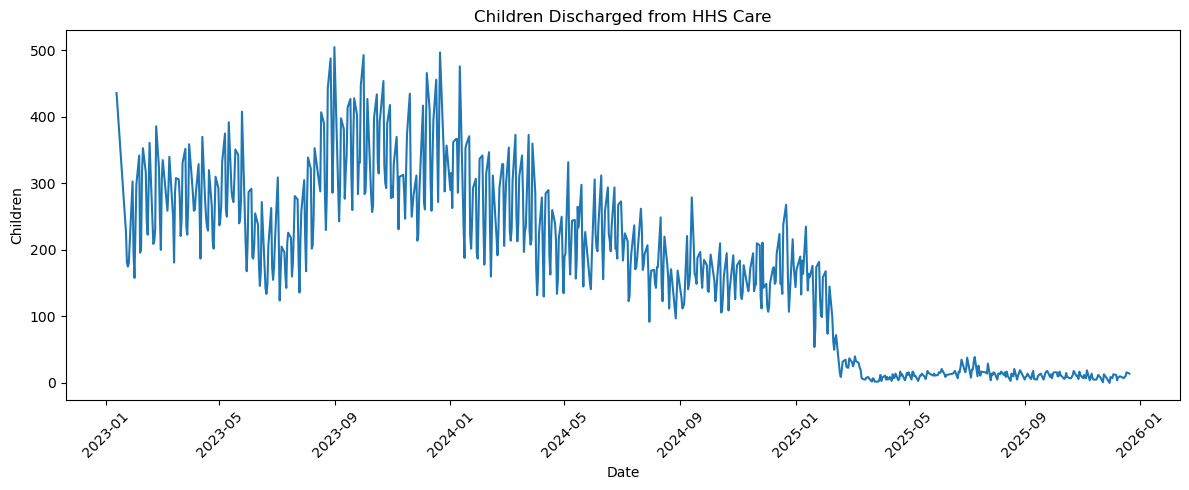

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children discharged from HHS Care"],
)

plt.title("Children Discharged from HHS Care")

plt.xlabel("Date")

plt.ylabel("Children")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Monthly Analysis

In [33]:
monthly = (
    df.groupby("Month_Num")
      .mean(numeric_only=True)
)

monthly

,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog
Month_Num,,,,,,,,,,
1,70.288462,116.557692,93.769231,6990.076923,224.653846,2024.269231,0.866442,0.032014,4.212224,-154.365385
2,115.775862,215.827586,160.517241,6335.741379,200.275862,2024.000000,0.833655,0.029167,3.599541,-84.500000
3,97.177419,191.516129,141.903226,6042.193548,183.258065,2024.048387,0.651893,0.024158,2.223634,-86.080645
4,102.151515,191.333333,142.045455,5629.924242,156.742424,2024.030303,0.655394,0.022006,1.584892,-54.590909
5,105.836066,206.967213,148.655738,6241.606557,177.000000,2023.934426,0.690916,0.023396,1.998733,-71.163934
6,90.913793,158.620690,128.206897,5528.586207,158.982759,2023.948276,0.725513,0.024676,2.357984,-68.068966
7,87.158730,157.222222,121.650794,5100.539683,138.126984,2024.000000,0.648282,0.022980,inf,-50.968254
8,93.457627,171.033898,123.389831,5780.762712,166.050847,2024.000000,0.605813,0.022504,inf,-72.593220
9,98.111111,183.825397,130.444444,6124.269841,166.269841,2024.047619,0.613672,0.020944,1.742623,-68.158730


Monthly Apprehensions

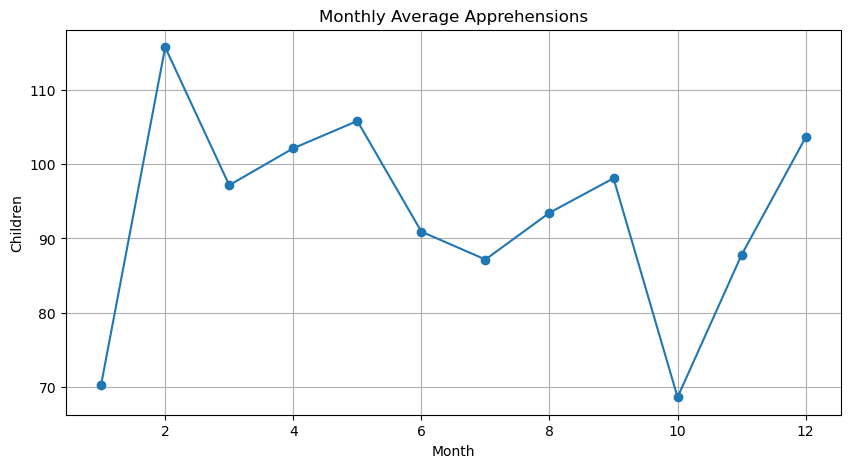

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly["Children apprehended and placed in CBP custody"],
    marker="o"
)

plt.title("Monthly Average Apprehensions")

plt.xlabel("Month")

plt.ylabel("Children")

plt.grid(True)

plt.show()

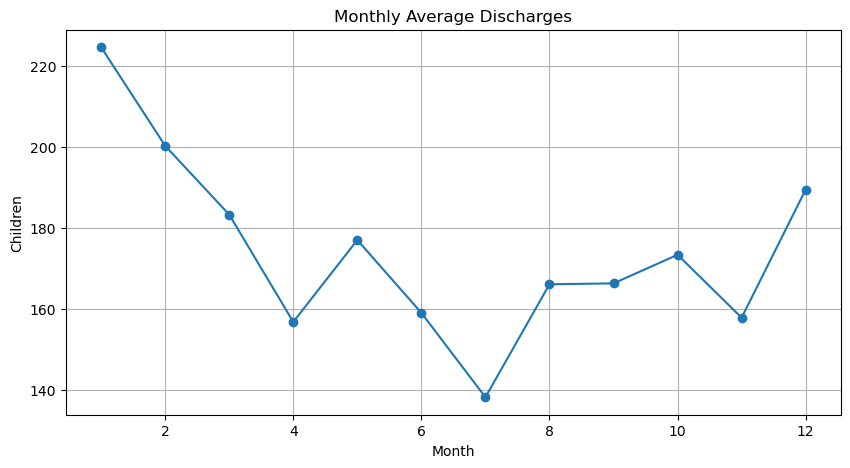

In [35]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly["Children discharged from HHS Care"],
    marker="o"
)

plt.title("Monthly Average Discharges")

plt.xlabel("Month")

plt.ylabel("Children")

plt.grid(True)

plt.show()

# Weekday Analysis

In [36]:
weekday = (
    df.groupby("Weekday")
      .mean(numeric_only=True)
)

weekday

,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month_Num,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog
Weekday,,,,,,,,,,,
Friday,44.500000,111.000000,110.000000,4296.500000,144.000000,2024.500000,6.500000,0.711818,0.024037,2.284722,-99.500000
Monday,93.779310,167.944828,123.731034,6063.517241,157.558621,2024.006897,6.531034,0.660516,0.021711,2.368546,-63.779310
Sunday,88.238462,169.392308,130.061538,5875.015385,206.138462,2024.038462,6.607692,0.700083,0.028396,inf,-117.900000
Thursday,94.693878,171.210884,133.414966,6128.789116,205.687075,2024.006803,6.503401,0.732629,0.027853,2.997023,-110.993197
Tuesday,97.114094,173.557047,124.859060,6082.436242,136.114094,2024.006711,6.536913,0.670485,0.018705,inf,-39.000000
Wednesday,93.802721,175.870748,131.673469,6158.829932,166.013605,2024.000000,6.476190,0.692006,0.022596,2.477646,-72.210884


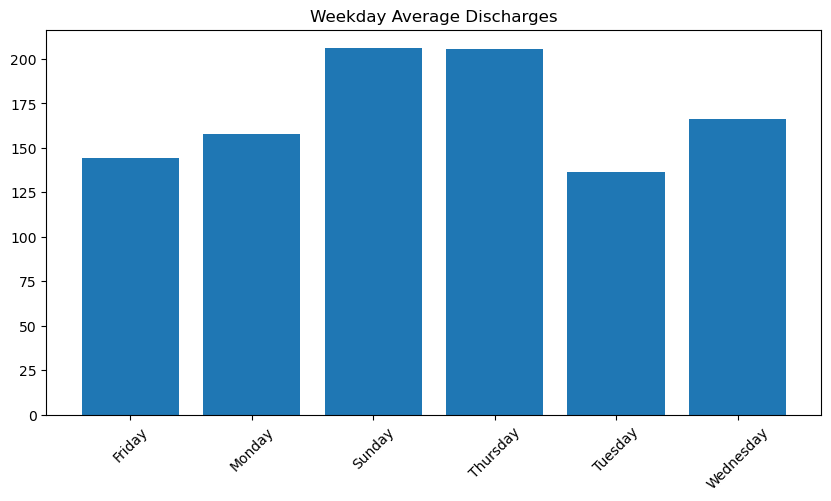

In [37]:
plt.figure(figsize=(10,5))

plt.bar(
    weekday.index,
    weekday["Children discharged from HHS Care"]
)

plt.title("Weekday Average Discharges")

plt.xticks(rotation=45)

plt.show()

# KPI Trends

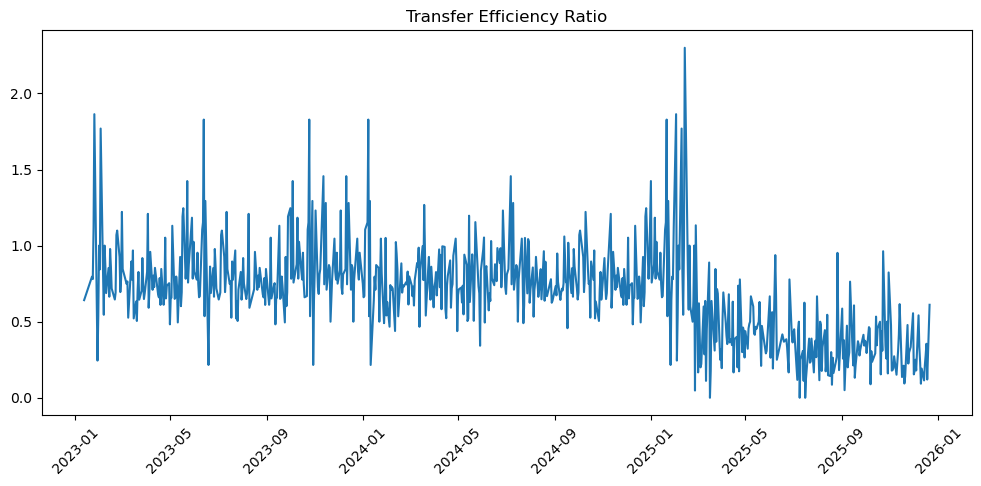

In [38]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Transfer Efficiency Ratio"]
)

plt.title("Transfer Efficiency Ratio")

plt.xticks(rotation=45)

plt.show()

Discharge Effectivness

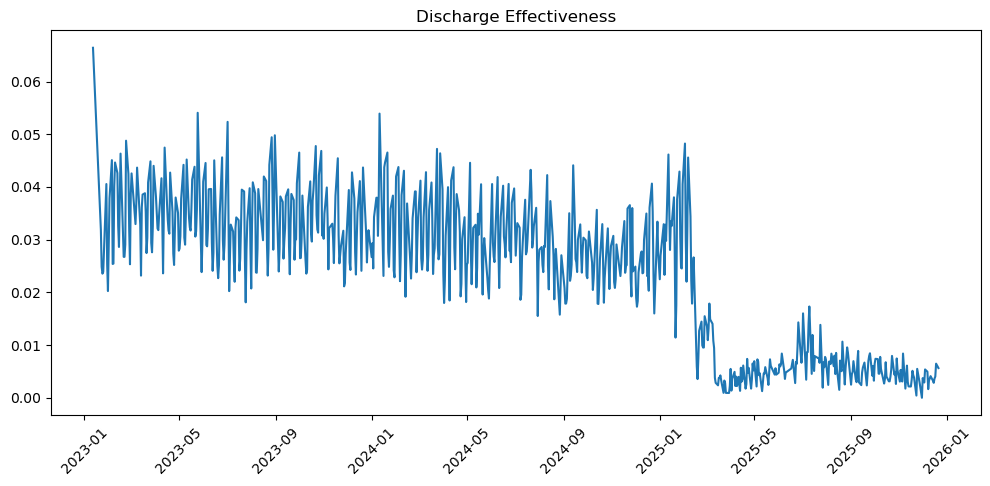

In [39]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Discharge Effectiveness"]
)

plt.title("Discharge Effectiveness")

plt.xticks(rotation=45)

plt.show()

Pipline Throughput

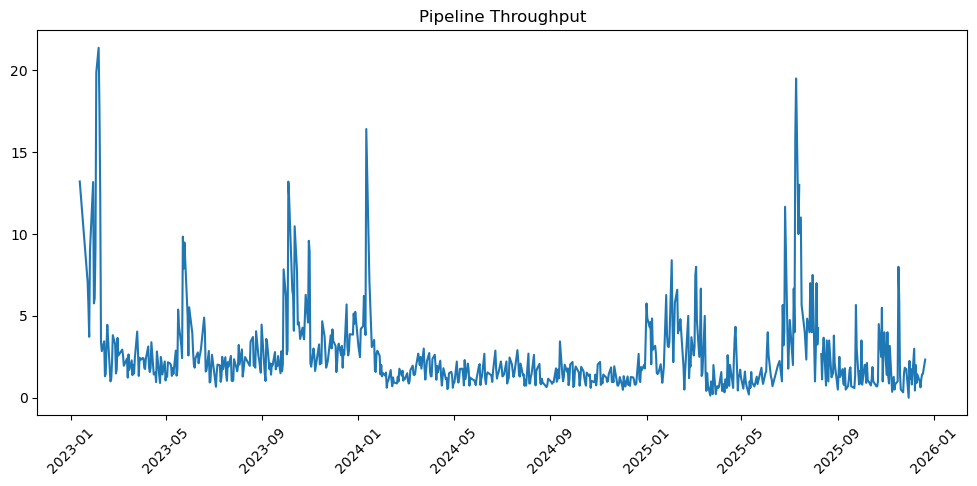

In [40]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Pipeline Throughput"]
)

plt.title("Pipeline Throughput")

plt.xticks(rotation=45)

plt.show()

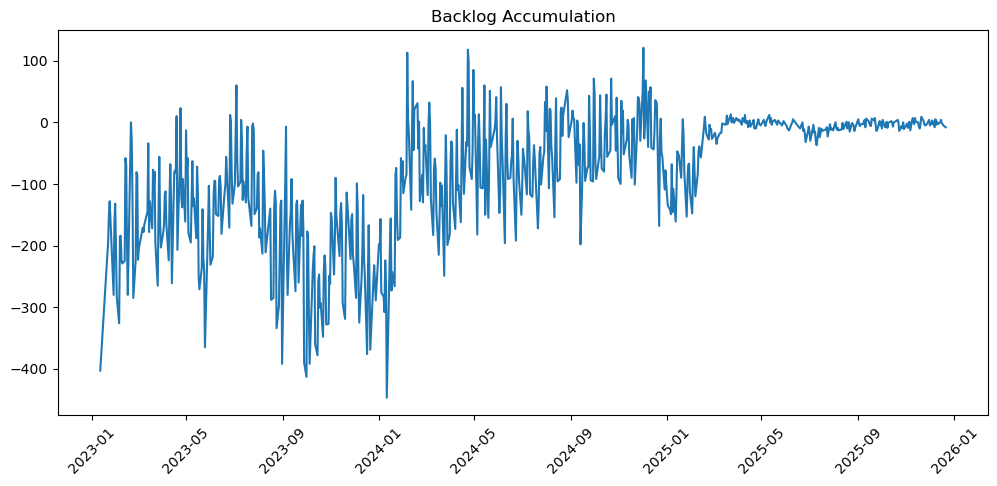

In [41]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Backlog"]
)

plt.title("Backlog Accumulation")

plt.xticks(rotation=45)

plt.show()

# Pipeline Summary

In [42]:
pipeline_summary = pd.DataFrame({
    "Stage": [
        "Children Apprehended",
        "Children in CBP Custody",
        "Transferred to HHS",
        "Children in HHS Care",
        "Children Discharged"
    ],
    "Average Count": [
        df["Children apprehended and placed in CBP custody"].mean(),
        df["Children in CBP custody"].mean(),
        df["Children transferred out of CBP custody"].mean(),
        df["Children in HHS Care"].mean(),
        df["Children discharged from HHS Care"].mean()
    ]
})

pipeline_summary

,Stage,Average Count
0,Children Apprehended,93.523611
1,Children in CBP Custody,171.494444
2,Transferred to HHS,128.668056
3,Children in HHS Care,6061.275000
4,Children Discharged,173.406944


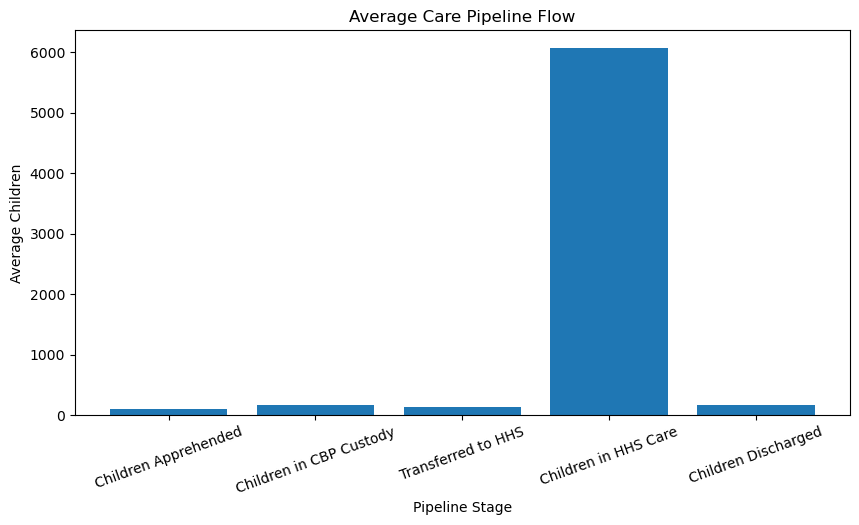

In [43]:
plt.figure(figsize=(10,5))

plt.bar(
    pipeline_summary["Stage"],
    pipeline_summary["Average Count"]
)

plt.title("Average Care Pipeline Flow")

plt.xlabel("Pipeline Stage")

plt.ylabel("Average Children")

plt.xticks(rotation=20)

plt.show()

# Pipeline Flow Chart (Simple)

Children Apprehended
        │
        ▼
Children in CBP Custody
        │
        ▼
Transferred to HHS
        │
        ▼
Children in HHS Care
        │
        ▼
Children Discharged

In [44]:
pipeline_summary["Percentage"] = (
    pipeline_summary["Average Count"] /
    pipeline_summary["Average Count"].iloc[0]
) * 100

pipeline_summary

,Stage,Average Count,Percentage
0,Children Apprehended,93.523611,100.000000
1,Children in CBP Custody,171.494444,183.370213
2,Transferred to HHS,128.668056,137.578152
3,Children in HHS Care,6061.275000,6481.010440
4,Children Discharged,173.406944,185.415151


# insight

# Avg Kpis values

In [45]:
print("="*50)
print("Transition Efficiency Metrics")
print("="*50)

print(f"Average Transfer Efficiency Ratio : {df['Transfer Efficiency Ratio'].mean():.2f}")

print(f"Average Discharge Effectiveness : {df['Discharge Effectiveness'].mean():.2f}")

print(f"Average Pipeline Throughput : {df['Pipeline Throughput'].mean():.2f}")

Transition Efficiency Metrics
Average Transfer Efficiency Ratio : 0.69
Average Discharge Effectiveness : 0.02
Average Pipeline Throughput : inf


Best & Worst Transfer Efficiency Day

best_transfer = df.loc[df["Transfer Efficiency Ratio"].idxmax()]

worst_transfer = df.loc[df["Transfer Efficiency Ratio"].idxmin()]

print("Best Transfer Efficiency Day")
display(best_transfer)

print("\nWorst Transfer Efficiency Day")
display(worst_transfer)

Best & Worst Discharge Effectiveness

In [46]:
best_discharge = df.loc[df["Discharge Effectiveness"].idxmax()]

worst_discharge = df.loc[df["Discharge Effectiveness"].idxmin()]

print("Best Discharge Effectiveness Day")
display(best_discharge)

print("\nWorst Discharge Effectiveness Day")
display(worst_discharge)

Best Discharge Effectiveness Day


Date                                              2023-01-12 00:00:00
Children apprehended and placed in CBP custody                   33.0
Children in CBP custody                                          53.0
Children transferred out of CBP custody                          34.0
Children in HHS Care                                             6566
Children discharged from HHS Care                               436.0
Year                                                             2023
Month                                                         January
Month_Num                                                           1
Weekday                                                      Thursday
Transfer Efficiency Ratio                                    0.641509
Discharge Effectiveness                                      0.066403
Pipeline Throughput                                         13.212121
Backlog                                                        -403.0
Name: 719, dtype: ob


Worst Discharge Effectiveness Day


Date                                              2025-11-30 00:00:00
Children apprehended and placed in CBP custody                    4.0
Children in CBP custody                                          18.0
Children transferred out of CBP custody                          10.0
Children in HHS Care                                             2415
Children discharged from HHS Care                                 0.0
Year                                                             2025
Month                                                        November
Month_Num                                                          11
Weekday                                                        Sunday
Transfer Efficiency Ratio                                    0.555556
Discharge Effectiveness                                           0.0
Pipeline Throughput                                               0.0
Backlog                                                           4.0
Name: 15, dtype: obj

Best & Worst Pipeline Throughput

In [47]:
best_pipeline = df.loc[df["Pipeline Throughput"].idxmax()]

worst_pipeline = df.loc[df["Pipeline Throughput"].idxmin()]

print("Best Pipeline Throughput Day")
display(best_pipeline)

print("\nWorst Pipeline Throughput Day")
display(worst_pipeline)

Best Pipeline Throughput Day


Date                                              2025-08-10 00:00:00
Children apprehended and placed in CBP custody                    0.0
Children in CBP custody                                          18.0
Children transferred out of CBP custody                           8.0
Children in HHS Care                                             2006
Children discharged from HHS Care                                12.0
Year                                                             2025
Month                                                          August
Month_Num                                                           8
Weekday                                                        Sunday
Transfer Efficiency Ratio                                    0.444444
Discharge Effectiveness                                      0.005982
Pipeline Throughput                                               inf
Backlog                                                         -12.0
Name: 91, dtype: obj


Worst Pipeline Throughput Day


Date                                              2025-11-30 00:00:00
Children apprehended and placed in CBP custody                    4.0
Children in CBP custody                                          18.0
Children transferred out of CBP custody                          10.0
Children in HHS Care                                             2415
Children discharged from HHS Care                                 0.0
Year                                                             2025
Month                                                        November
Month_Num                                                          11
Weekday                                                        Sunday
Transfer Efficiency Ratio                                    0.555556
Discharge Effectiveness                                           0.0
Pipeline Throughput                                               0.0
Backlog                                                           4.0
Name: 15, dtype: obj

KPI Summary Table

In [48]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Transfer Efficiency Ratio",
        "Discharge Effectiveness",
        "Pipeline Throughput"
    ],
    "Average": [
        df["Transfer Efficiency Ratio"].mean(),
        df["Discharge Effectiveness"].mean(),
        df["Pipeline Throughput"].mean()
    ],
    "Maximum": [
        df["Transfer Efficiency Ratio"].max(),
        df["Discharge Effectiveness"].max(),
        df["Pipeline Throughput"].max()
    ],
    "Minimum": [
        df["Transfer Efficiency Ratio"].min(),
        df["Discharge Effectiveness"].min(),
        df["Pipeline Throughput"].min()
    ]
})

kpi_summary

,Metric,Average,Maximum,Minimum
0,Transfer Efficiency Ratio,0.691018,2.300000,0.0
1,Discharge Effectiveness,0.023737,0.066403,0.0
2,Pipeline Throughput,inf,inf,0.0


# Backlog summary

In [49]:
print("="*50)
print("Backlog Summary")
print("="*50)

print(f"Average Backlog : {df['Backlog'].mean():.2f}")

print(f"Maximum Backlog : {df['Backlog'].max():.2f}")

print(f"Minimum Backlog : {df['Backlog'].min():.2f}")

Backlog Summary
Average Backlog : -79.88
Maximum Backlog : 121.00
Minimum Backlog : -447.00


In [50]:
highest_backlog = df.loc[df["Backlog"].idxmax()]

print("Highest Backlog Day")

display(highest_backlog)

Highest Backlog Day


Date                                              2024-12-02 00:00:00
Children apprehended and placed in CBP custody                  236.0
Children in CBP custody                                         330.0
Children transferred out of CBP custody                         222.0
Children in HHS Care                                             6061
Children discharged from HHS Care                               115.0
Year                                                             2024
Month                                                        December
Month_Num                                                          12
Weekday                                                        Monday
Transfer Efficiency Ratio                                    0.672727
Discharge Effectiveness                                      0.018974
Pipeline Throughput                                          0.487288
Backlog                                                         121.0
Name: 259, dtype: ob

In [51]:
lowest_backlog = df.loc[df["Backlog"].idxmin()]

print("Lowest Backlog Day")

display(lowest_backlog)

Lowest Backlog Day


Date                                              2024-01-11 00:00:00
Children apprehended and placed in CBP custody                   29.0
Children in CBP custody                                          51.0
Children transferred out of CBP custody                          11.0
Children in HHS Care                                             8829
Children discharged from HHS Care                               476.0
Year                                                             2024
Month                                                         January
Month_Num                                                           1
Weekday                                                      Thursday
Transfer Efficiency Ratio                                    0.215686
Discharge Effectiveness                                      0.053913
Pipeline Throughput                                         16.413793
Backlog                                                        -447.0
Name: 481, dtype: ob

In [52]:
top10_backlog = (
    df.sort_values("Backlog", ascending=False)
      [["Date", "Backlog"]]
      .head(10)
)

top10_backlog

,Date,Backlog
259,2024-12-02,121.0
410,2024-04-23,118.0
464,2024-02-06,113.0
409,2024-04-24,99.0
405,2024-04-30,85.0
286,2024-10-22,71.0
301,2024-09-30,71.0
256,2024-12-05,68.0
459,2024-02-13,67.0
395,2024-05-14,60.0


In [53]:
lowest10_backlog = (
    df.sort_values("Backlog")
      [["Date", "Backlog"]]
      .head(10)
)

lowest10_backlog

,Date,Backlog
481,2024-01-11,-447.0
550,2023-10-01,-413.0
719,2023-01-12,-403.0
570,2023-08-31,-392.0
546,2023-10-05,-392.0
551,2023-09-28,-390.0
541,2023-10-15,-378.0
498,2023-12-17,-376.0
494,2023-12-21,-369.0
634,2023-05-25,-365.0


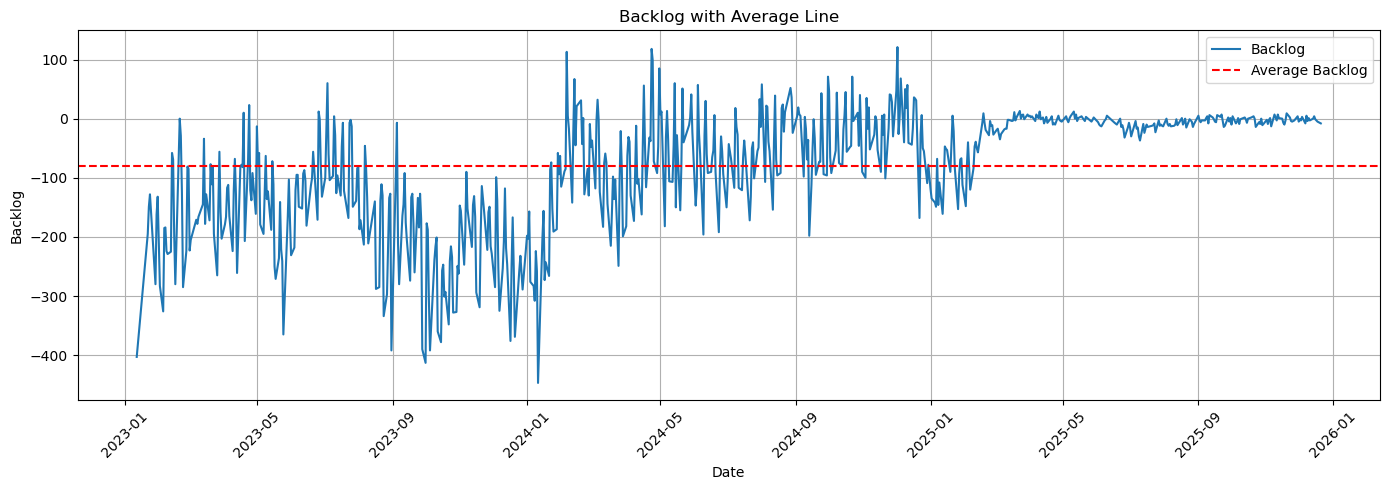

In [54]:
plt.figure(figsize=(14,5))

plt.plot(df["Date"], df["Backlog"], label="Backlog")

plt.axhline(
    df["Backlog"].mean(),
    color="red",
    linestyle="--",
    label="Average Backlog"
)

plt.title("Backlog with Average Line")

plt.xlabel("Date")

plt.ylabel("Backlog")

plt.legend()

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [55]:
delay_periods = df[
    df["Backlog"] > df["Backlog"].mean()
]

print("Number of Delay Days :", len(delay_periods))

delay_periods[["Date", "Backlog"]].head()

Number of Delay Days : 416


,Date,Backlog
0,2025-12-21,-8.0
1,2025-12-18,-5.0
2,2025-12-17,-3.0
3,2025-12-16,-1.0
4,2025-12-15,4.0


In [56]:
delay_percentage = (
    len(delay_periods) / len(df)
) * 100

print(f"Delay Days Percentage : {delay_percentage:.2f}%")

Delay Days Percentage : 57.78%


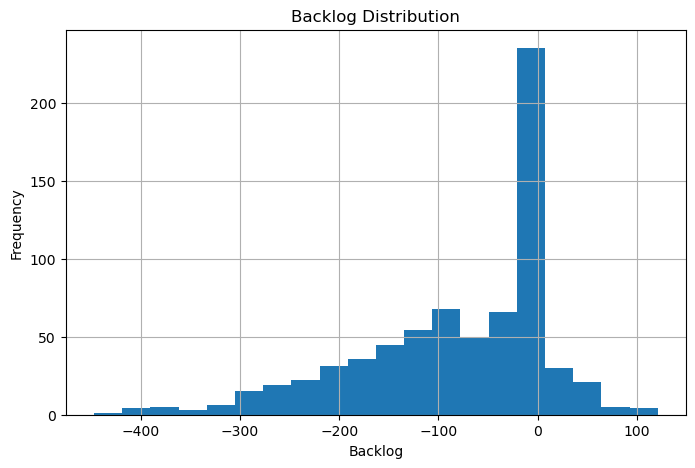

In [57]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Backlog"],
    bins=20
)

plt.title("Backlog Distribution")

plt.xlabel("Backlog")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [58]:
df

,Date,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Month_Num,Weekday,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog
0,2025-12-21,6.0,18.0,11.0,2484,14.0,2025,December,12,Sunday,0.611111,0.005636,2.333333,-8.0
1,2025-12-18,11.0,50.0,6.0,2472,16.0,2025,December,12,Thursday,0.120000,0.006472,1.454545,-5.0
2,2025-12-17,7.0,31.0,11.0,2481,10.0,2025,December,12,Wednesday,0.354839,0.004031,1.428571,-3.0
3,2025-12-16,8.0,54.0,15.0,2468,9.0,2025,December,12,Tuesday,0.277778,0.003647,1.125000,-1.0
4,2025-12-15,11.0,42.0,9.0,2470,7.0,2025,December,12,Monday,0.214286,0.002834,0.636364,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2023-01-25,20.0,22.0,41.0,7538,180.0,2023,January,1,Wednesday,1.863636,0.023879,9.000000,-160.0
716,2023-01-24,47.0,42.0,47.0,7433,175.0,2023,January,1,Tuesday,1.119048,0.023544,3.723404,-128.0
717,2023-01-23,32.0,50.0,39.0,7280,181.0,2023,January,1,Monday,0.780000,0.024863,5.656250,-149.0
718,2023-01-22,32.0,49.0,39.0,7122,227.0,2023,January,1,Sunday,0.795918,0.031873,7.093750,-195.0


Temporal & pattern Analysis

In [59]:
df["Day"] = df["Date"].dt.day

In [60]:
df

,Date,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Month_Num,Weekday,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog,Day
0,2025-12-21,6.0,18.0,11.0,2484,14.0,2025,December,12,Sunday,0.611111,0.005636,2.333333,-8.0,21
1,2025-12-18,11.0,50.0,6.0,2472,16.0,2025,December,12,Thursday,0.120000,0.006472,1.454545,-5.0,18
2,2025-12-17,7.0,31.0,11.0,2481,10.0,2025,December,12,Wednesday,0.354839,0.004031,1.428571,-3.0,17
3,2025-12-16,8.0,54.0,15.0,2468,9.0,2025,December,12,Tuesday,0.277778,0.003647,1.125000,-1.0,16
4,2025-12-15,11.0,42.0,9.0,2470,7.0,2025,December,12,Monday,0.214286,0.002834,0.636364,4.0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2023-01-25,20.0,22.0,41.0,7538,180.0,2023,January,1,Wednesday,1.863636,0.023879,9.000000,-160.0,25
716,2023-01-24,47.0,42.0,47.0,7433,175.0,2023,January,1,Tuesday,1.119048,0.023544,3.723404,-128.0,24
717,2023-01-23,32.0,50.0,39.0,7280,181.0,2023,January,1,Monday,0.780000,0.024863,5.656250,-149.0,23
718,2023-01-22,32.0,49.0,39.0,7122,227.0,2023,January,1,Sunday,0.795918,0.031873,7.093750,-195.0,22


In [61]:
monthly = df.groupby("Month").agg({
    "Children apprehended and placed in CBP custody":"mean",
    "Children transferred out of CBP custody":"mean",
    "Children discharged from HHS Care":"mean",
    "Backlog":"mean"
})

monthly

,Children apprehended and placed in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care,Backlog
Month,,,,
April,102.151515,142.045455,156.742424,-54.590909
August,93.457627,123.389831,166.050847,-72.593220
December,103.625000,136.142857,189.464286,-85.839286
February,115.775862,160.517241,200.275862,-84.500000
January,70.288462,93.769231,224.653846,-154.365385
July,87.158730,121.650794,138.126984,-50.968254
June,90.913793,128.206897,158.982759,-68.068966
March,97.177419,141.903226,183.258065,-86.080645
May,105.836066,148.655738,177.000000,-71.163934


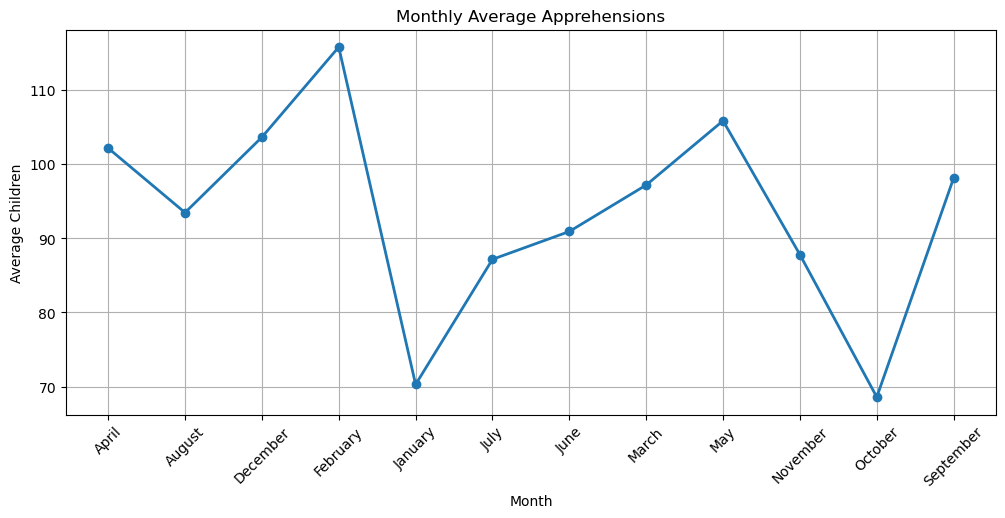

In [62]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly["Children apprehended and placed in CBP custody"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Average Apprehensions")

plt.xlabel("Month")

plt.ylabel("Average Children")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [63]:
df["Day_Type"] = df["Weekday"].apply(
    lambda x: "Weekend" if x in ["Saturday","Sunday"] else "Weekday"
)

In [64]:
df

,Date,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Month_Num,Weekday,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog,Day,Day_Type
0,2025-12-21,6.0,18.0,11.0,2484,14.0,2025,December,12,Sunday,0.611111,0.005636,2.333333,-8.0,21,Weekend
1,2025-12-18,11.0,50.0,6.0,2472,16.0,2025,December,12,Thursday,0.120000,0.006472,1.454545,-5.0,18,Weekday
2,2025-12-17,7.0,31.0,11.0,2481,10.0,2025,December,12,Wednesday,0.354839,0.004031,1.428571,-3.0,17,Weekday
3,2025-12-16,8.0,54.0,15.0,2468,9.0,2025,December,12,Tuesday,0.277778,0.003647,1.125000,-1.0,16,Weekday
4,2025-12-15,11.0,42.0,9.0,2470,7.0,2025,December,12,Monday,0.214286,0.002834,0.636364,4.0,15,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2023-01-25,20.0,22.0,41.0,7538,180.0,2023,January,1,Wednesday,1.863636,0.023879,9.000000,-160.0,25,Weekday
716,2023-01-24,47.0,42.0,47.0,7433,175.0,2023,January,1,Tuesday,1.119048,0.023544,3.723404,-128.0,24,Weekday
717,2023-01-23,32.0,50.0,39.0,7280,181.0,2023,January,1,Monday,0.780000,0.024863,5.656250,-149.0,23,Weekday
718,2023-01-22,32.0,49.0,39.0,7122,227.0,2023,January,1,Sunday,0.795918,0.031873,7.093750,-195.0,22,Weekend


In [65]:
weekday_weekend = df.groupby("Day_Type").agg({
    "Transfer Efficiency Ratio":"mean",
    "Discharge Effectiveness":"mean",
    "Pipeline Throughput":"mean",
    "Backlog":"mean"
})

weekday_weekend

,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog
Day_Type,,,,
Weekday,0.689020,0.022711,inf,-71.50678
Weekend,0.700083,0.028396,inf,-117.90000


C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


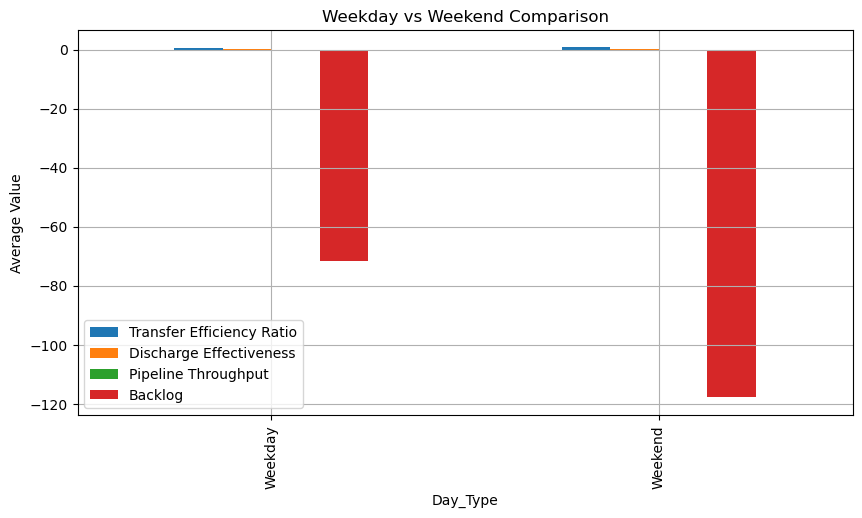

In [66]:
weekday_weekend.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Weekday vs Weekend Comparison")

plt.ylabel("Average Value")

plt.grid(True)

plt.show()

In [67]:
df

,Date,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Month_Num,Weekday,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog,Day,Day_Type
0,2025-12-21,6.0,18.0,11.0,2484,14.0,2025,December,12,Sunday,0.611111,0.005636,2.333333,-8.0,21,Weekend
1,2025-12-18,11.0,50.0,6.0,2472,16.0,2025,December,12,Thursday,0.120000,0.006472,1.454545,-5.0,18,Weekday
2,2025-12-17,7.0,31.0,11.0,2481,10.0,2025,December,12,Wednesday,0.354839,0.004031,1.428571,-3.0,17,Weekday
3,2025-12-16,8.0,54.0,15.0,2468,9.0,2025,December,12,Tuesday,0.277778,0.003647,1.125000,-1.0,16,Weekday
4,2025-12-15,11.0,42.0,9.0,2470,7.0,2025,December,12,Monday,0.214286,0.002834,0.636364,4.0,15,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2023-01-25,20.0,22.0,41.0,7538,180.0,2023,January,1,Wednesday,1.863636,0.023879,9.000000,-160.0,25,Weekday
716,2023-01-24,47.0,42.0,47.0,7433,175.0,2023,January,1,Tuesday,1.119048,0.023544,3.723404,-128.0,24,Weekday
717,2023-01-23,32.0,50.0,39.0,7280,181.0,2023,January,1,Monday,0.780000,0.024863,5.656250,-149.0,23,Weekday
718,2023-01-22,32.0,49.0,39.0,7122,227.0,2023,January,1,Sunday,0.795918,0.031873,7.093750,-195.0,22,Weekend


In [68]:
import numpy as np

df["Pipeline Throughput"] = np.where(
    df["Children apprehended and placed in CBP custody"] == 0,
    np.nan,
    df["Children discharged from HHS Care"] /
    df["Children apprehended and placed in CBP custody"]
)

In [69]:
df["Pipeline Throughput"].describe()

count    718.000000
mean       2.503247
std        2.470397
min        0.000000
25%        1.152592
50%        1.779040
75%        2.878137
max       21.375000
Name: Pipeline Throughput, dtype: float64

In [70]:
import numpy as np

print(np.isinf(df["Pipeline Throughput"]).sum())

0


In [71]:
stagnation = df[
    df["Backlog"] > df["Backlog"].mean()
]

stagnation[["Date","Backlog"]].head()

,Date,Backlog
0,2025-12-21,-8.0
1,2025-12-18,-5.0
2,2025-12-17,-3.0
3,2025-12-16,-1.0
4,2025-12-15,4.0


In [72]:
print("Total Stagnation Days :", len(stagnation))

Total Stagnation Days : 416


In [73]:
stagnation.sort_values(
    "Backlog",
    ascending=False
).head(10)

,Date,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Month_Num,Weekday,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput,Backlog,Day,Day_Type
259,2024-12-02,236.0,330.0,222.0,6061,115.0,2024,December,12,Monday,0.672727,0.018974,0.487288,121.0,2,Weekday
410,2024-04-23,252.0,427.0,307.0,6967,134.0,2024,April,4,Tuesday,0.718970,0.019234,0.531746,118.0,23,Weekday
464,2024-02-06,291.0,455.0,323.0,8045,178.0,2024,February,2,Tuesday,0.709890,0.022126,0.611684,113.0,6,Weekday
409,2024-04-24,253.0,411.0,307.0,7128,154.0,2024,April,4,Wednesday,0.746959,0.021605,0.608696,99.0,24,Weekday
405,2024-04-30,220.0,443.0,194.0,7431,135.0,2024,April,4,Tuesday,0.437923,0.018167,0.613636,85.0,30,Weekday
286,2024-10-22,180.0,280.0,146.0,6043,109.0,2024,October,10,Tuesday,0.521429,0.018037,0.605556,71.0,22,Weekday
301,2024-09-30,209.0,285.0,184.0,5967,138.0,2024,September,9,Monday,0.645614,0.023127,0.660287,71.0,30,Weekday
256,2024-12-05,218.0,283.0,208.0,6310,150.0,2024,December,12,Thursday,0.734982,0.023772,0.688073,68.0,5,Weekday
459,2024-02-13,227.0,369.0,349.0,8348,160.0,2024,February,2,Tuesday,0.945799,0.019166,0.704846,67.0,13,Weekday
609,2023-07-04,184.0,314.0,217.0,6127,124.0,2023,July,7,Tuesday,0.691083,0.020238,0.673913,60.0,4,Weekday


In [74]:
monthly_growth = monthly.pct_change()*100

monthly_growth

,Children apprehended and placed in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care,Backlog
Month,,,,
April,NaN,NaN,NaN,NaN
August,-8.510777,-13.133559,5.938675,32.976757
December,10.879126,10.335557,14.100162,18.246973
February,11.725802,17.903535,5.706393,-1.560225
January,-39.289192,-41.583079,12.172203,82.680929
July,24.001477,29.734234,-38.515638,-66.982070
June,4.308304,5.389281,15.098986,33.551692
March,6.889633,10.682989,15.269144,26.460928
May,8.910142,4.758533,-3.414892,-17.328763


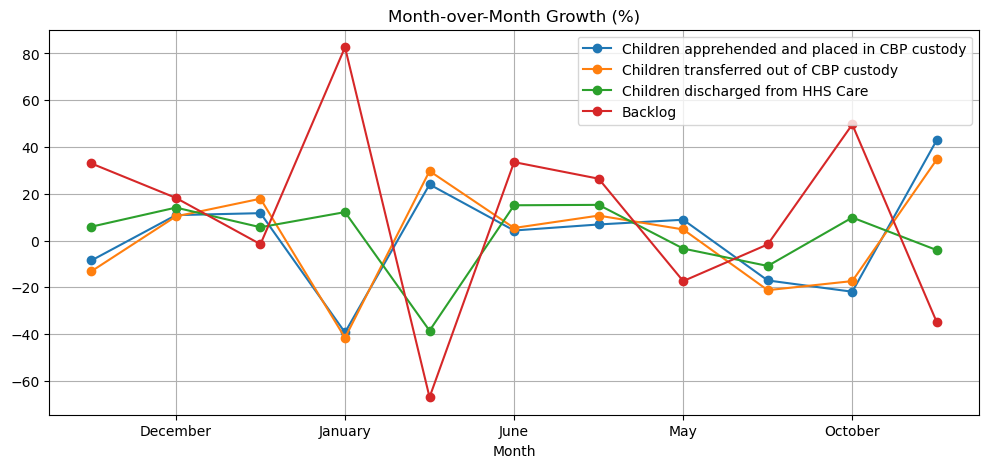

In [75]:
monthly_growth.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Month-over-Month Growth (%)")

plt.grid(True)

plt.show()

In [76]:
summary = pd.DataFrame({
    "Metric":[
        "Average Transfer Efficiency",
        "Average Discharge Effectiveness",
        "Average Pipeline Throughput",
        "Average Backlog"
    ],
    "Value":[
        df["Transfer Efficiency Ratio"].mean(),
        df["Discharge Effectiveness"].mean(),
        df["Pipeline Throughput"].mean(),
        df["Backlog"].mean()
    ]
})

summary

,Metric,Value
0,Average Transfer Efficiency,0.691018
1,Average Discharge Effectiveness,0.023737
2,Average Pipeline Throughput,2.503247
3,Average Backlog,-79.883333


Rolling Mean

In [78]:
df["Rolling Mean"] = (
    df["Children discharged from HHS Care"]
    .rolling(window=7)
    .mean()
)

Rolling sd

In [79]:
df["Rolling Std"] = (
    df["Children discharged from HHS Care"]
    .rolling(window=7)
    .std()
)

Rolling Mean Trend Chart

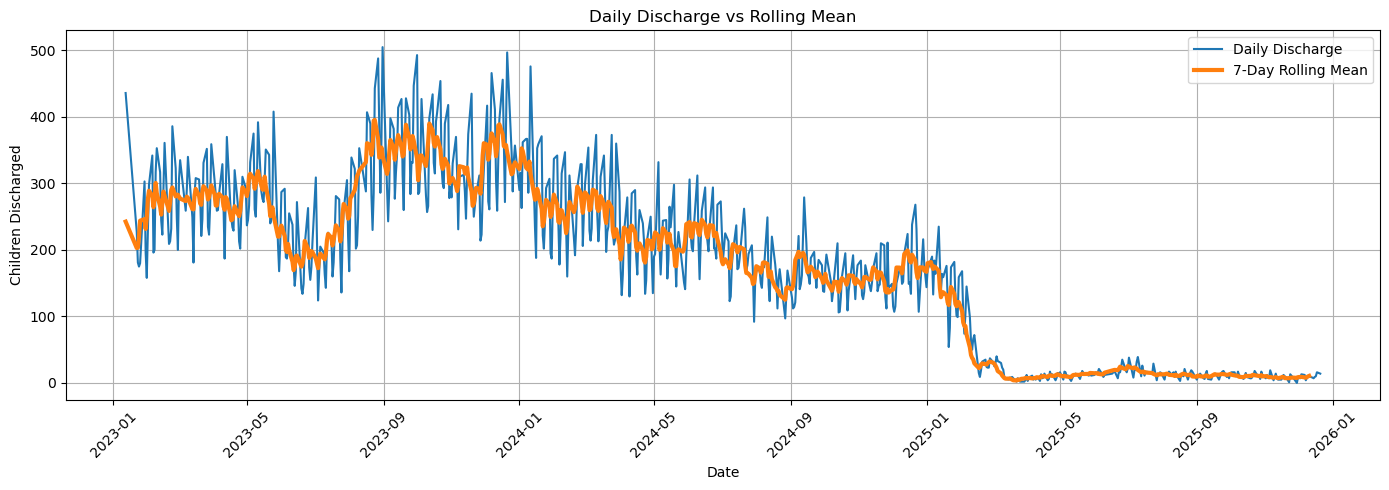

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    df["Date"],
    df["Children discharged from HHS Care"],
    label="Daily Discharge"
)

plt.plot(
    df["Date"],
    df["Rolling Mean"],
    linewidth=3,
    label="7-Day Rolling Mean"
)

plt.title("Daily Discharge vs Rolling Mean")

plt.xlabel("Date")

plt.ylabel("Children Discharged")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Rolling Standard Deviation Chart

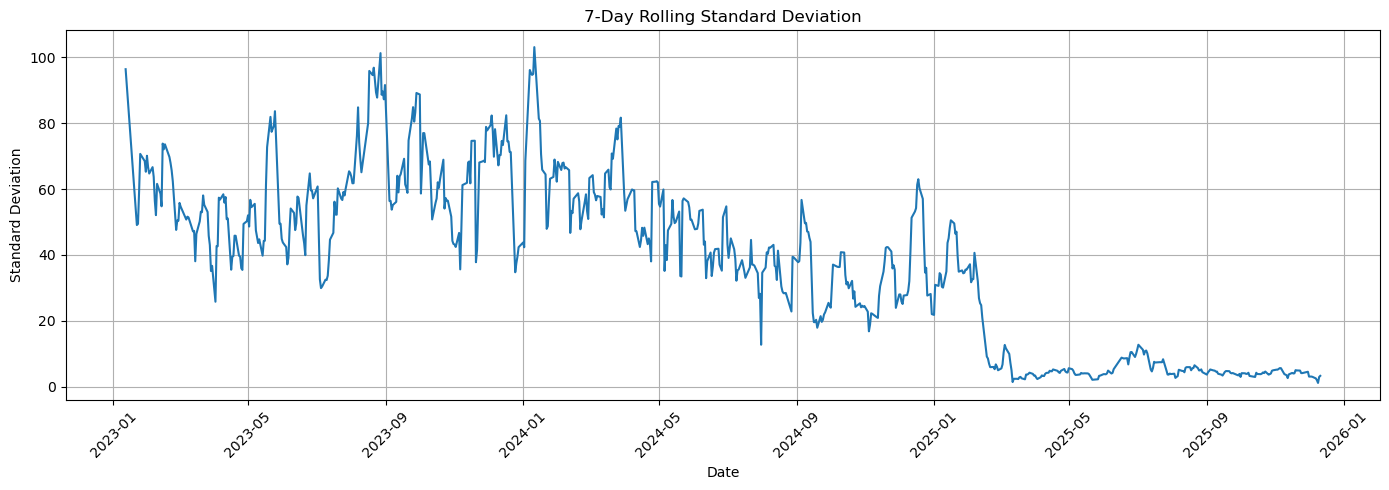

In [81]:
plt.figure(figsize=(14,5))

plt.plot(
    df["Date"],
    df["Rolling Std"]
)

plt.title("7-Day Rolling Standard Deviation")

plt.xlabel("Date")

plt.ylabel("Standard Deviation")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Sudden Drop Detection

In [82]:
df["Discharge Change (%)"] = (
    df["Children discharged from HHS Care"]
    .pct_change()*100
)

In [83]:
sudden_drop = df[
    df["Discharge Change (%)"] < -20
]

print("Total Sudden Drop Days:", len(sudden_drop))

sudden_drop[[
    "Date",
    "Children discharged from HHS Care",
    "Discharge Change (%)"
]].head(10)

Total Sudden Drop Days: 184


,Date,Children discharged from HHS Care,Discharge Change (%)
2,2025-12-17,10.0,-37.500000
4,2025-12-15,7.0,-22.222222
9,2025-12-08,4.0,-50.000000
12,2025-12-03,7.0,-46.153846
15,2025-11-30,0.0,-100.000000
19,2025-11-23,1.0,-92.307692
23,2025-11-17,8.0,-33.333333
24,2025-11-16,5.0,-37.500000
28,2025-11-09,4.0,-71.428571
30,2025-11-05,7.0,-63.157895


In [87]:
import numpy as np

df["Discharge Change (%)"] = (
    df["Children discharged from HHS Care"].pct_change() * 100
)

df["Discharge Change (%)"] = df["Discharge Change (%)"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [89]:
sudden_increase = df[df["Discharge Change (%)"] > 20]

print("Total Sudden Increase Days:", len(sudden_increase))

sudden_increase[[
    "Date",
    "Children discharged from HHS Care",
    "Discharge Change (%)"
]].head(10)

Total Sudden Increase Days: 214


,Date,Children discharged from HHS Care,Discharge Change (%)
6,2025-12-11,10.0,25.000000
10,2025-12-07,12.0,200.000000
17,2025-11-25,11.0,57.142857
20,2025-11-20,9.0,800.000000
26,2025-11-12,7.0,40.000000
27,2025-11-11,14.0,100.000000
29,2025-11-06,19.0,375.000000
32,2025-11-03,12.0,50.000000
34,2025-10-30,12.0,71.428571
35,2025-10-29,17.0,41.666667


Sudden Increase Detection

In [90]:
df["Previous Discharge"] = df["Children discharged from HHS Care"].shift(1)

sudden_increase = df[df["Discharge Change (%)"] > 20]

sudden_increase[[
    "Date",
    "Previous Discharge",
    "Children discharged from HHS Care",
    "Discharge Change (%)"
]].head(10)

,Date,Previous Discharge,Children discharged from HHS Care,Discharge Change (%)
6,2025-12-11,8.0,10.0,25.000000
10,2025-12-07,4.0,12.0,200.000000
17,2025-11-25,7.0,11.0,57.142857
20,2025-11-20,1.0,9.0,800.000000
26,2025-11-12,5.0,7.0,40.000000
27,2025-11-11,7.0,14.0,100.000000
29,2025-11-06,4.0,19.0,375.000000
32,2025-11-03,8.0,12.0,50.000000
34,2025-10-30,7.0,12.0,71.428571
35,2025-10-29,12.0,17.0,41.666667


Stability Score

In [86]:
stability_score = (
    df["Children discharged from HHS Care"].std()
)

print("Outcome Stability Score:", stability_score)

Outcome Stability Score: 125.7028405572817


Summary 

In [91]:
stability_summary = df[[
    "Children discharged from HHS Care",
    "Rolling Mean",
    "Rolling Std"
]].describe()

stability_summary

,Children discharged from HHS Care,Rolling Mean,Rolling Std
count,720.000000,714.000000,714.000000
mean,173.406944,173.680472,37.977961
std,125.702841,118.070926,25.481410
min,0.000000,3.714286,1.112697
25%,19.750000,21.821429,7.716988
50%,181.000000,189.285714,40.647433
75%,267.000000,269.714286,57.051457
max,505.000000,395.571429,103.098196


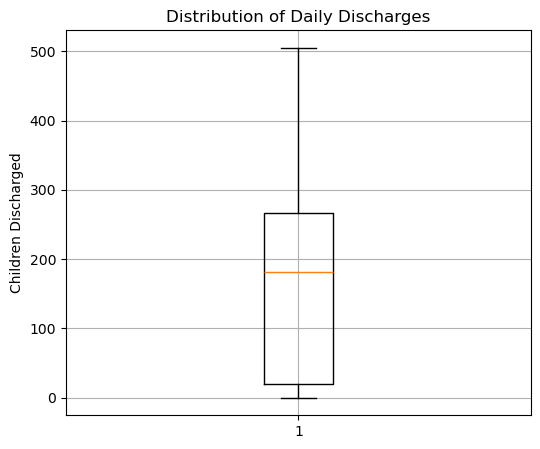

In [92]:
plt.figure(figsize=(6,5))

plt.boxplot(
    df["Children discharged from HHS Care"].dropna()
)

plt.title("Distribution of Daily Discharges")

plt.ylabel("Children Discharged")

plt.grid(True)

plt.show()

The outcome stability analysis identified several days with significant increases in discharge counts. For example, on 20 November 2025, discharges increased from 1 to 9, resulting in an 800% increase. Such large percentage changes are primarily due to a very low discharge count on the previous day rather than an error in the data. Similar spikes on other dates may indicate backlog clearance, increased processing capacity, or operational improvements.